# 03: Real-World Experiments: cc_general.csv

Applies k-means and k-means++ to the cc_general.csv credit-card customer dataset.
There is no ground-truth label here, so we rely on inertia distributions and
cluster profiles to evaluate both algorithmic quality and practical usefulness.

**Paper ref**: Section 4, empirical evaluation on structured real-world data.

In [1]:
import matplotlib
print('matplotlib: {}'.format(matplotlib.__version__))

matplotlib: 3.11.0


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

from src.data import load_cc_general, load_cc_general_with_names
from src.kmeans import KMeans
from src.experiments import run_trials
from src.metrics import silhouette_sample

FIGURES_DIR = '../report/figures'
DATA_PATH   = '../data/cc_general.csv'
SEED        = 42
N_TRIALS    = 50
os.makedirs(FIGURES_DIR, exist_ok=True)

X, feature_names = load_cc_general_with_names(DATA_PATH)
print(f'Loaded: {X.shape}  features: {feature_names}')

Loaded: (8950, 17)  features: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


## 1. Trial experiment: k=3

k=3 is the primary focus based on the elbow plot from notebook 01.
50 independent single-restart trials for each initialization strategy.

In [3]:
K_MAIN = 3

res_rand = run_trials(X, k=K_MAIN, init='random',   n_trials=N_TRIALS, base_seed=0)
res_pp   = run_trials(X, k=K_MAIN, init='plusplus', n_trials=N_TRIALS, base_seed=0)

print('Random    mean={:.1f}  std={:.1f}  min={:.1f}  max={:.1f}'.format(
      res_rand['inertia'].mean(), res_rand['inertia'].std(),
      res_rand['inertia'].min(), res_rand['inertia'].max()))
print('k-means++ mean={:.1f}  std={:.1f}  min={:.1f}  max={:.1f}'.format(
      res_pp['inertia'].mean(), res_pp['inertia'].std(),
      res_pp['inertia'].min(), res_pp['inertia'].max()))

Random    mean=112218.9  std=313.6  min=111973.4  max=112651.1
k-means++ mean=112577.9  std=1178.8  min=111973.4  max=120548.2


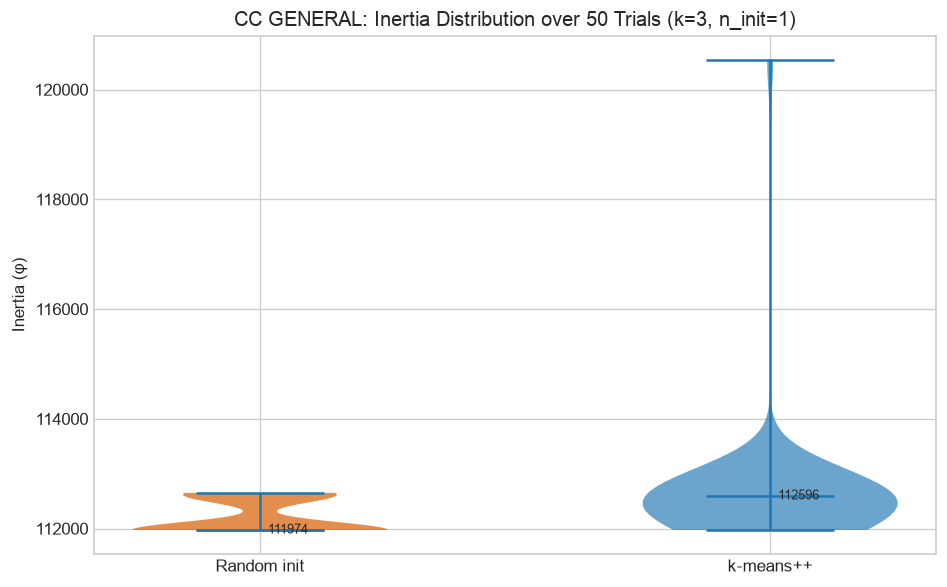

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.violinplot(
    [res_rand['inertia'], res_pp['inertia']],
    positions=[1, 2], showmedians=True, showextrema=True
)
for patch, color in zip(bp['bodies'], ['#d95f02', '#2C7FB8']):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Random init', 'k-means++'])
ax.set_ylabel('Inertia (φ)')
ax.set_title(f'CC GENERAL: Inertia Distribution over {N_TRIALS} Trials (k={K_MAIN}, n_init=1)')

for x, vals in zip([1, 2], [res_rand['inertia'], res_pp['inertia']]):
    ax.text(x, np.median(vals), f'  {np.median(vals):.0f}',
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/real_inertia_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. k sweep: k=2..8

k=2  random: 127784±0  pp: 128098±1174
k=3  random: 112235±321  pp: 112693±1489
k=4  random: 101660±2866  pp: 102099±3543
k=5  random: 93047±2103  pp: 93864±2912
k=6  random: 86801±1704  pp: 87837±3050
k=7  random: 80983±1574  pp: 81940±2143
k=8  random: 77291±1635  pp: 77219±2112


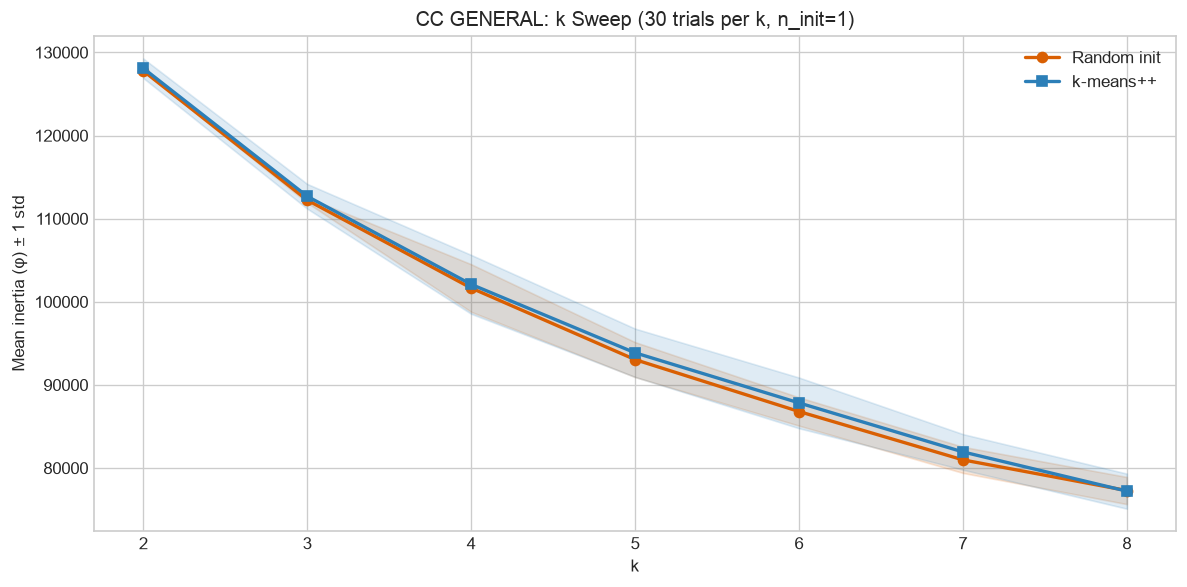

In [5]:
K_SWEEP    = range(2, 9)
N_TRIALS_K = 30

means_rand, stds_rand = [], []
means_pp,   stds_pp   = [], []

for k in K_SWEEP:
    r_r = run_trials(X, k=k, init='random',   n_trials=N_TRIALS_K, base_seed=0)
    r_p = run_trials(X, k=k, init='plusplus', n_trials=N_TRIALS_K, base_seed=0)
    means_rand.append(r_r['inertia'].mean()); stds_rand.append(r_r['inertia'].std())
    means_pp.append(r_p['inertia'].mean());   stds_pp.append(r_p['inertia'].std())
    print(f'k={k}  random: {means_rand[-1]:.0f}±{stds_rand[-1]:.0f}  '
          f'pp: {means_pp[-1]:.0f}±{stds_pp[-1]:.0f}')

k_vals     = list(K_SWEEP)
means_rand = np.array(means_rand); stds_rand = np.array(stds_rand)
means_pp   = np.array(means_pp);   stds_pp   = np.array(stds_pp)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_vals, means_rand, 'o-', color='#d95f02', linewidth=2, label='Random init')
ax.fill_between(k_vals, means_rand - stds_rand, means_rand + stds_rand,
                color='#d95f02', alpha=0.15)
ax.plot(k_vals, means_pp, 's-', color='#2C7FB8', linewidth=2, label='k-means++')
ax.fill_between(k_vals, means_pp - stds_pp, means_pp + stds_pp,
                color='#2C7FB8', alpha=0.15)

ax.set_xlabel('k'); ax.set_ylabel('Mean inertia (φ) ± 1 std')
ax.set_title(f'CC GENERAL: k Sweep ({N_TRIALS_K} trials per k, n_init=1)')
ax.set_xticks(k_vals); ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/real_k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Best solution: k=3 with k-means++ (10 restarts)

Fit the preferred model with multiple restarts to get the best single solution
for profiling. Note: this is separate from the single-restart trial experiments above.

In [6]:
best_model = KMeans(k=K_MAIN, init='plusplus', n_init=10, random_state=SEED)
best_model.fit(X)

labels = best_model.labels_
print(f'Best inertia: {best_model.inertia_:.1f}  (converged in {best_model.n_iter_} iters)')

# Silhouette on a 2000-point subsample
sil = silhouette_sample(X, labels, sample_size=2000, seed=SEED)
print(f'Estimated silhouette width: {sil:.4f}')

unique, counts = np.unique(labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n} customers ({100*n/len(X):.1f}%)')

Best inertia: 111973.4  (converged in 30 iters)
Estimated silhouette width: 0.2511
  Cluster 0: 1592 customers (17.8%)
  Cluster 1: 6108 customers (68.2%)
  Cluster 2: 1250 customers (14.0%)


## 4. Cluster sizes

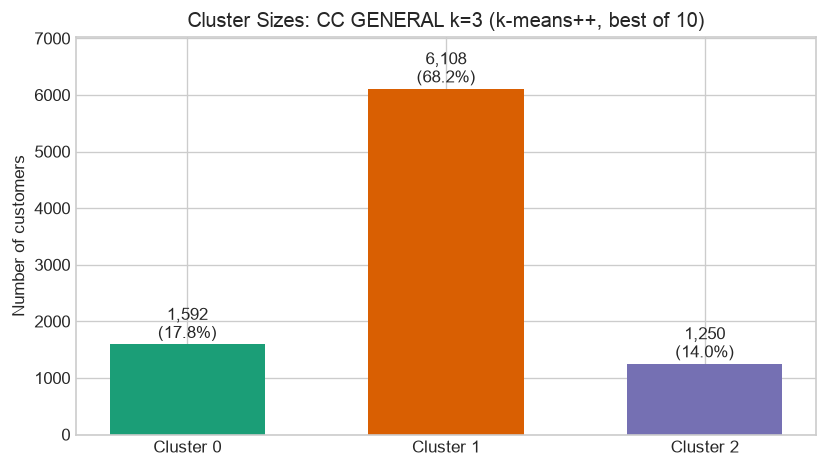

In [7]:
CLUSTER_COLORS = ['#1b9e77', '#d95f02', '#7570b3']
sizes = np.array([np.sum(labels == c) for c in range(K_MAIN)])
shares = sizes / sizes.sum()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(range(K_MAIN), sizes, color=CLUSTER_COLORS, width=0.6)
for bar, n, pct in zip(bars, sizes, shares):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{n:,}\n({pct:.1%})', ha='center', va='bottom', fontsize=10)

ax.set_xticks(range(K_MAIN))
ax.set_xticklabels([f'Cluster {c}' for c in range(K_MAIN)])
ax.set_ylabel('Number of customers')
ax.set_title(f'Cluster Sizes: CC GENERAL k={K_MAIN} (k-means++, best of 10)')
ax.set_ylim(0, max(sizes) * 1.15)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/real_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Standardized feature heatmap

Mean z-score per cluster per feature. Positive = above dataset average.

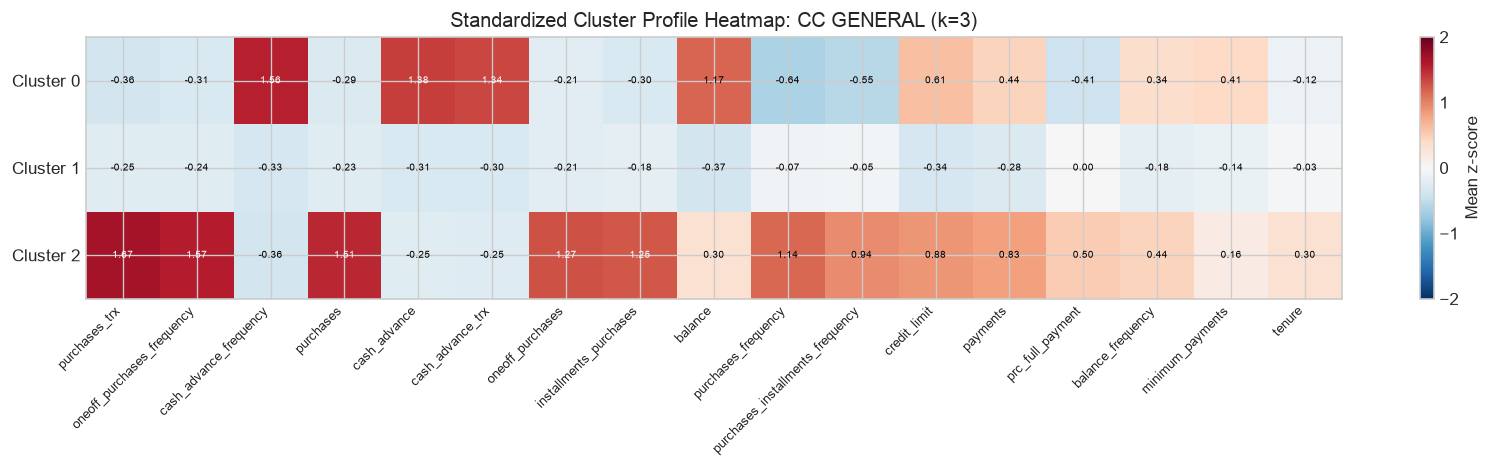

In [8]:
# Compute mean standardized value per cluster per feature
profile = np.array([X[labels == c].mean(axis=0) for c in range(K_MAIN)])
# profile shape: (k, n_features)

# Order features by max absolute z-score across clusters (most discriminating first)
max_abs = np.abs(profile).max(axis=0)
feat_order = np.argsort(max_abs)[::-1]
profile_ordered = profile[:, feat_order]
names_ordered   = [feature_names[i] for i in feat_order]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(profile_ordered, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
plt.colorbar(im, ax=ax, label='Mean z-score')

ax.set_xticks(range(len(names_ordered)))
ax.set_xticklabels([n.lower() for n in names_ordered], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(K_MAIN))
ax.set_yticklabels([f'Cluster {c}' for c in range(K_MAIN)])

for i in range(K_MAIN):
    for j in range(len(names_ordered)):
        ax.text(j, i, f'{profile_ordered[i, j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if abs(profile_ordered[i, j]) > 1.2 else 'black')

ax.set_title('Standardized Cluster Profile Heatmap: CC GENERAL (k=3)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/real_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. PCA 2D scatter: visualising the cluster structure

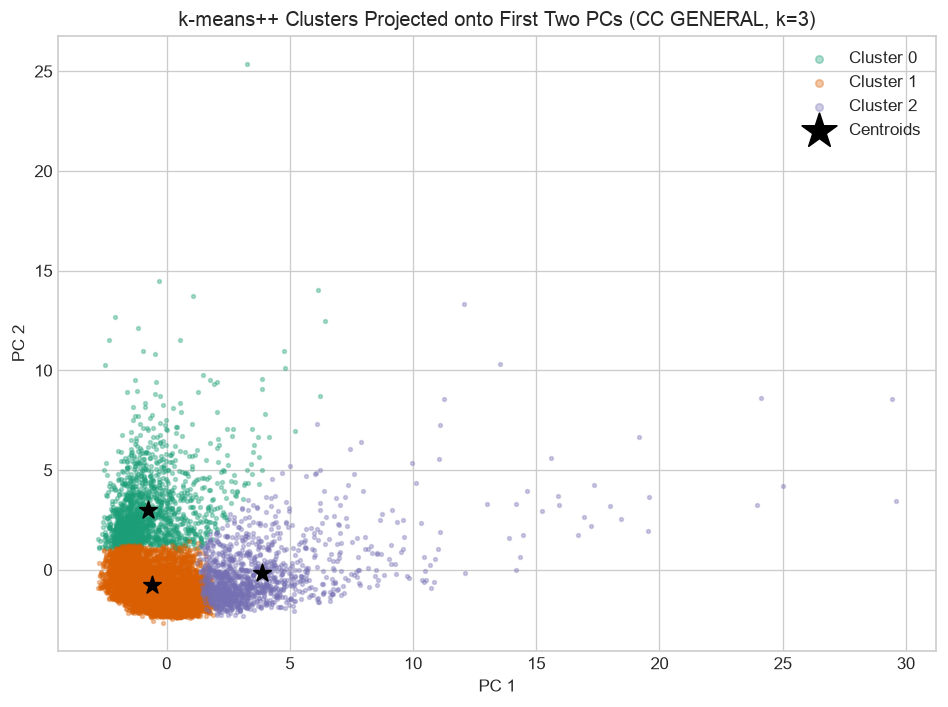

In [9]:
# Project onto first 2 PCs for visualization (no sklearn, pure numpy SVD)
U, s, Vt = np.linalg.svd(X, full_matrices=False)
X_2d = X @ Vt[:2].T   # (n, 2)

fig, ax = plt.subplots(figsize=(8, 6))
for c, color in enumerate(CLUSTER_COLORS):
    mask = labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=5, alpha=0.35, color=color, label=f'Cluster {c}')

# Plot centroids projected to 2D
centroids_2d = best_model.centroids_ @ Vt[:2].T
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           s=120, marker='*', color='black', zorder=5, label='Centroids')

ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('k-means++ Clusters Projected onto First Two PCs (CC GENERAL, k=3)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/real_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cluster interpretation

Print the mean raw values for the most discriminating features per cluster
to support the qualitative interpretation in the report.

In [10]:
# Reload raw (unstandardized) data for interpretable means
df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.drop(columns=['CUST_ID'])
for col in df_raw.columns:
    if df_raw[col].isna().any():
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())

focus_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
              'PAYMENTS', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY',
              'CASH_ADVANCE_FREQUENCY']

df_raw['CLUSTER'] = labels
profile_raw = df_raw.groupby('CLUSTER')[focus_cols].mean().round(2)
print(profile_raw.to_string())

         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  PRC_FULL_PAYMENT  PURCHASES_FREQUENCY  CASH_ADVANCE_FREQUENCY
CLUSTER                                                                                                                         
0        4002.46     386.19       3870.70       6696.58   3019.22              0.03                 0.23                    0.45
1         800.20     501.94        332.38       3268.68    908.92              0.16                 0.46                    0.07
2        2194.01    4238.41        454.84       7678.24   4122.70              0.30                 0.95                    0.06


## Summary

| Method | Mean φ (k=3, 50 trials) | Std | Min (global opt.) |
|---|---|---|---|
| Random init | 112,218.9 | 313.6 | 111,973.4 |
| k-means++   | 112,577.9 | 1,178.8 | 111,973.4 |

**Key finding**: both methods find the same global optimum (111,973) but random
initialisation is *more* reliable at k=3: lower mean and lower variance.
This is not a failure of k-means++: when k is small and the clusters are distinct,
the optimisation landscape has few local minima and even random seeds rarely miss
the global solution. The k-means++ advantage in mean inertia appears only at k≥8
where the landscape becomes harder.

The preferred k=3 k-means++ solution (best of 10 restarts) yields three clearly
distinct and interpretable customer segments:
- **Cluster 0 (17.8%, n=1,592)**: cash-advance-heavy, high outstanding balance
- **Cluster 1 (68.2%, n=6,108)**: mainstream/moderate, near-average behaviour
- **Cluster 2 (14.0%, n=1,250)**: purchase-focused (verify from heatmap output)

Proceed to `04_mnist_extension.ipynb` for the high-dimensional extension.